# **Course-end Project: Marketing Campaigns**

## **Problem scenario:**
Marketing mix stands as a widely utilized concept in the execution of marketing strategies. It encompasses various facets within a comprehensive marketing plan, with a central focus on the four Ps of marketing: product, price, place, and promotion.

## **Problem objective:**
As a data scientist, you must conduct exploratory data analysis and hypothesis testing to enhance your comprehension of the diverse factors influencing customer acquisition.

## **Data description:**
The variables such as birth year, education, income, and others pertain to the first 'P' or 'People' in the tabular data presented to the user. The expenditures on items like wine, fruits, and gold, are associated with ‘Product’. Information relevant to sales channels, such as websites and stores, is connected to ‘Place’, and the fields discussing promotions and the outcomes of various campaigns are linked to ‘Promotion’.



## **Steps to perform:**

### 1.	After importing the data, examine variables such as Dt_Customer and Income to verify their accurate importation.

In [1]:
# Importing packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import scipy.stats as stats
from scipy.stats.mstats import winsorize

# Reading csv file
data = pd.read_csv("/content/marketing_data.csv")

# Using data.head to shows top 5 records. We will use it to check that all the rows and column seems proper and loaded succesfully by pandas
data.head()



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [2]:
# Using data.info(), we can examine the columns and it's data types. We can ue this informtion to decide if any column data type needs to be corrected to ease of use
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [3]:
# for ease of use, making all columns starting with lower case. Also removing extra spaces in column names.
data.columns = data.columns.str.replace(' ', '').str.lower()
data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country'],
      dtype='object')

In [4]:
# Dt_Customer column is of type object. For ease of use, we will covert it to datetime
data.dt_customer = pd.to_datetime(data.dt_customer)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2216 non-null   object        
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

/tmp/ipykernel_1418/3110012664.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.dt_customer = pd.to_datetime(data.dt_customer)


In [5]:
# Transform income column to a numerical
data.income = data.income.str.replace('$', '').str.replace(',', '').astype('float')
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,response,complain,country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2216 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

In [7]:
# Inference for step 1:
# 1. Making all columns starting with lower case. Also removing extra spaces in column names.
# 2. Dt_Customer column is of type object. For ease of use, we will covert it to datetime
# 3. Transform income column to a numerical


### 2.	There are missing income values for some customers. Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average. It may be necessary to cleanse the data before proceeding. Specifically, scrutinize the categories of education and marital status for data cleaning.



In [8]:
# Check for null values present in columns
data.isnull().sum()

,0
id,0
year_birth,0
education,0
marital_status,0
income,24
kidhome,0
teenhome,0
dt_customer,0
recency,0
mntwines,0


In [9]:
# List down marital_status categories
data.marital_status.unique()

array(['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO',
       'Alone', 'Absurd'], dtype=object)

In [10]:
# re-categotize the marital_status into 'couple' and 'alone'
def change(x):
  if x in ['Married', 'Together']:
    return 'couple'
  else :
    return 'alone'
data.marital_status = data.marital_status.apply(change)

data.marital_status.unique()

array(['alone', 'couple'], dtype=object)

In [11]:
# check unique values for education column
data.education.unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [12]:
# calculates the average income for combinations of education and marital status
agg_data = data.groupby(['education', 'marital_status'])[['income']].mean().unstack()['income']
agg_data

marital_status,alone,couple
education,,
2n Cycle,51957.984375,45597.992647
Basic,17998.350000,21663.852941
Graduation,52615.569652,52779.380952
Master,53170.472000,52785.795833
PhD,54050.657143,57343.238562


In [13]:
# Conducting missing value imputation considering,
# customers with similar education and marital status tend to have comparable yearly incomes, on average

for edu in data.education.unique():
  for status in data.marital_status.unique():
    val = agg_data.loc[edu, status]
    data.loc[(data.education == edu) & (data.marital_status == status) & (data.income.isnull()),'income'] = val

# vaildate that no null in columns
data.isnull().sum()

,0
id,0
year_birth,0
education,0
marital_status,0
income,0
kidhome,0
teenhome,0
dt_customer,0
recency,0
mntwines,0


### 3.	Create variables to represent the total number of children, age, and total spending.

a.	Derive the total purchases from the number of transactions across the three channels.


In [14]:
# Create variables to represent the total number of children, age, total spending, total purchase and education years
data['age'] = 2026 - data.year_birth
data['spending'] = data.loc[:,data.columns.str.startswith('mnt')].sum(axis = 1)
data['children_count'] = data.kidhome + data.teenhome
data['has_children'] = np.where((data.kidhome + data.teenhome) > 0, 1,0)
data['total_purchases'] = data.loc[:, data.columns.str.endswith('purchases')].sum(axis = 1)
data['education_years'] = data.education.replace({'Basic':5,'2n Cycle':8,'Graduation':12,'Master':18,'PhD':21})

data.head()

/tmp/ipykernel_1418/1204464153.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['education_years'] = data.education.replace({'Basic':5,'2n Cycle':8,'Graduation':12,'Master':18,'PhD':21})


,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp2,response,complain,country,age,spending,children_count,has_children,total_purchases,education_years
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,1,0,SP,56,1190,0,0,15,12
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,1,1,0,CA,65,577,0,0,18,12
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,US,68,251,1,1,11,12
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,AUS,59,11,2,1,4,12
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,1,0,SP,37,91,1,1,8,12


### 4.	Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.

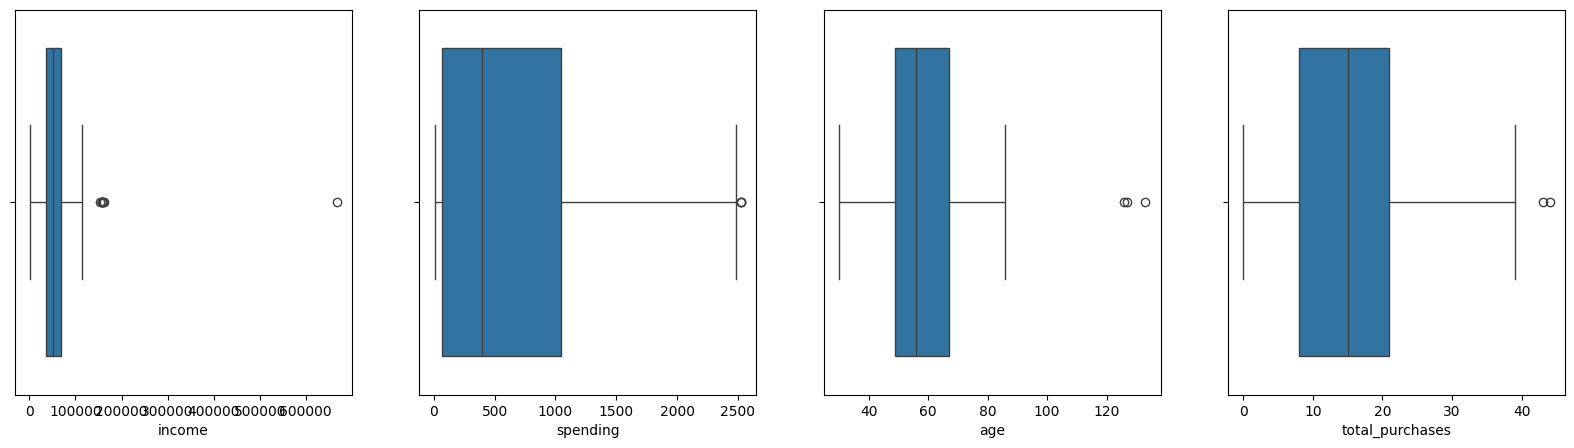

In [15]:
# side-by-side boxplots to visualize the distribution and detect outliers for all your numeric variables.
num_vars = ['income', 'spending', 'age', 'total_purchases']

f,ax = plt.subplots(1, len(num_vars), figsize = (20,5))
i = 0
for v in num_vars:
  sns.boxplot(x = data[v], ax = ax[i])
  i += 1
plt.show()

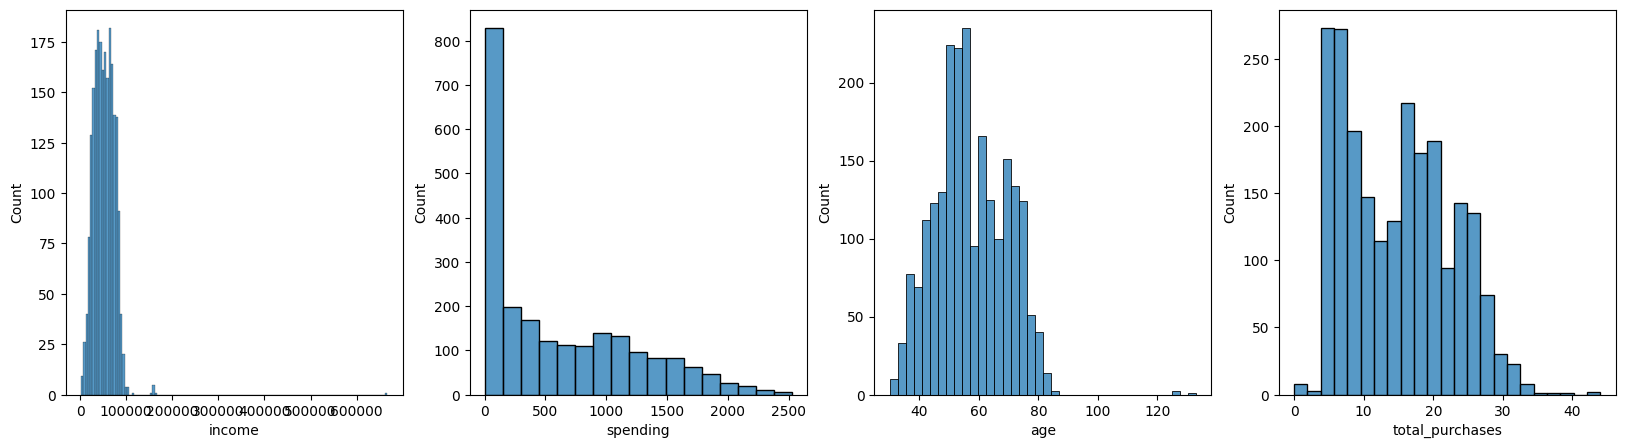

In [16]:
# side-by-side histograms using Seaborn to visualize the underlying distribution shape

f,ax = plt.subplots(1, len(num_vars), figsize = (20,5))
i = 0
for v in num_vars:
  sns.histplot(x = data[v], ax = ax[i])
  i += 1
plt.show()

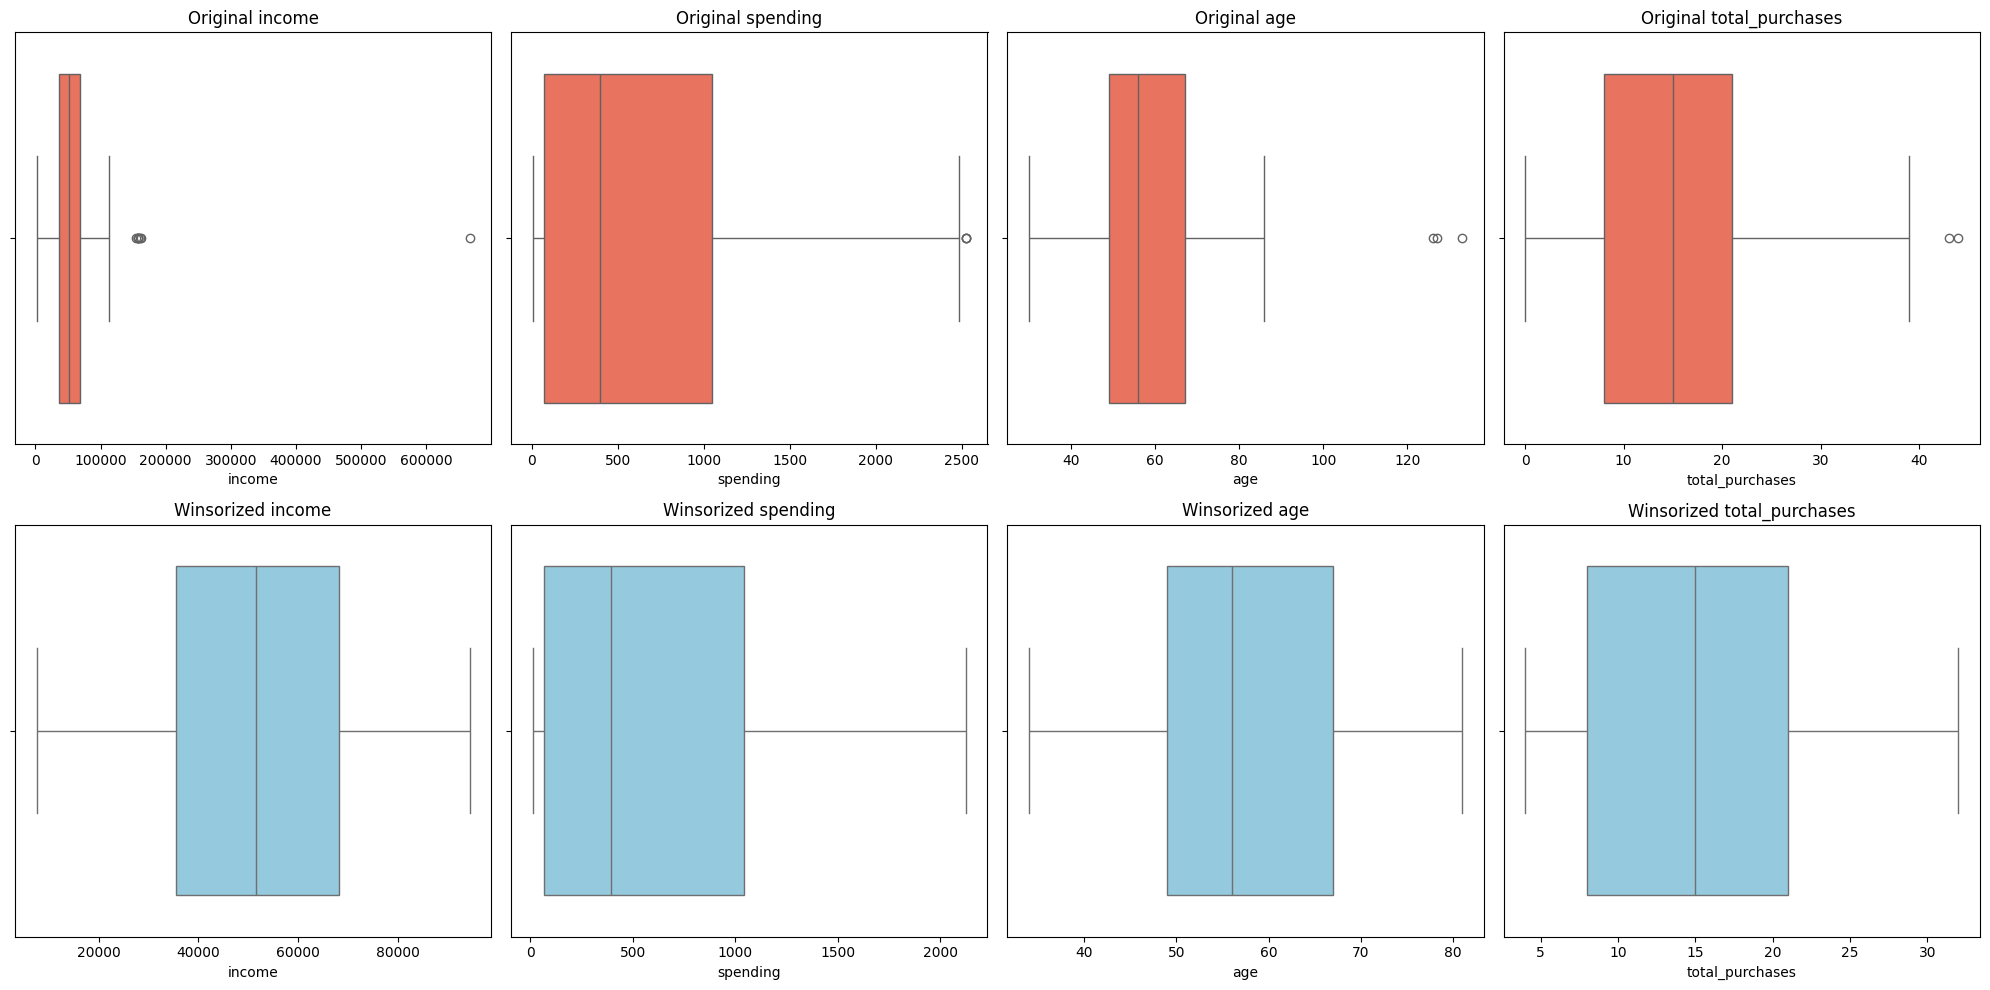

In [17]:
# perform winsorze and do the outlier treatment

# Create a copy to preserve original data
data_treated = data.copy()
data_treated.head()
for v in num_vars:
    # Check if the column has missing values before winsorizing
    if data_treated[v].isnull().any():
        print(f"Warning: {v} contains NaN values. Handle missing values first.")
        continue

    # limits=[0.01, 0.01] cuts off lowest 1% and highest 1% of data
    data_treated[v] = winsorize(data_treated[v], limits=[0.01, 0.01])


# We create 2 rows: Row 1 = Original, Row 2 = Treated
f, ax = plt.subplots(2, len(num_vars), figsize=(20, 10), squeeze=False)

for i, v in enumerate(num_vars):
    # Row 0: Original Data Boxplot
    sns.boxplot(x=data[v], ax=ax[0, i], color='tomato')
    ax[0, i].set_title(f'Original {v}')

    # Row 1: Treated Data Boxplot
    sns.boxplot(x=data_treated[v], ax=ax[1, i], color='skyblue')
    ax[1, i].set_title(f'Winsorized {v}')

plt.tight_layout()
plt.show()


### 5.	Apply ordinal and one-hot encoding based on the various types of categorical variables.

In [18]:
#For eductaion we use ordinal encoder
ord = OrdinalEncoder(categories = [['Basic','2n Cycle','Graduation', 'Master','PhD']])
ord.fit(data[['education']])
data['education_encode'] = ord.transform(data[['education']]).flatten()
data.education_encode.unique()

array([2., 4., 1., 3., 0.])

In [19]:
#For country and marital status use one hot encoding
ohe = OneHotEncoder()
country_encode = pd.DataFrame(ohe.fit_transform(data[['country']]).toarray().astype(int),
             columns = ohe.categories_[0])
country_encode

,AUS,CA,GER,IND,ME,SA,SP,US
0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...
2235,0,0,0,0,0,0,0,1
2236,0,0,0,0,0,0,1,0
2237,0,0,0,0,0,0,1,0
2238,0,0,0,1,0,0,0,0


In [20]:
marital_status_encode = pd.DataFrame(ohe.fit_transform(data[['marital_status']]).toarray().astype(int),
             columns = ohe.categories_[0])
marital_status_encode

,alone,couple
0,1,0
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
2235,1,0
2236,0,1
2237,1,0
2238,0,1


In [21]:
new_data = pd.concat([data,pd.get_dummies(data[['country', 'marital_status']], dtype = int)], axis = 1)
new_data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,country_AUS,country_CA,country_GER,country_IND,country_ME,country_SA,country_SP,country_US,marital_status_alone,marital_status_couple
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,0,0,0,0,1,0,1,0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,1,0,0,0,0,0,0,1,0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,0,0,1,0,1
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,1,0,0,0,0,0,0,0,0,1
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,0,0,0,0,0,1,0,1,0


### 6.	Generate a heatmap to illustrate the correlation between different pairs of variables.

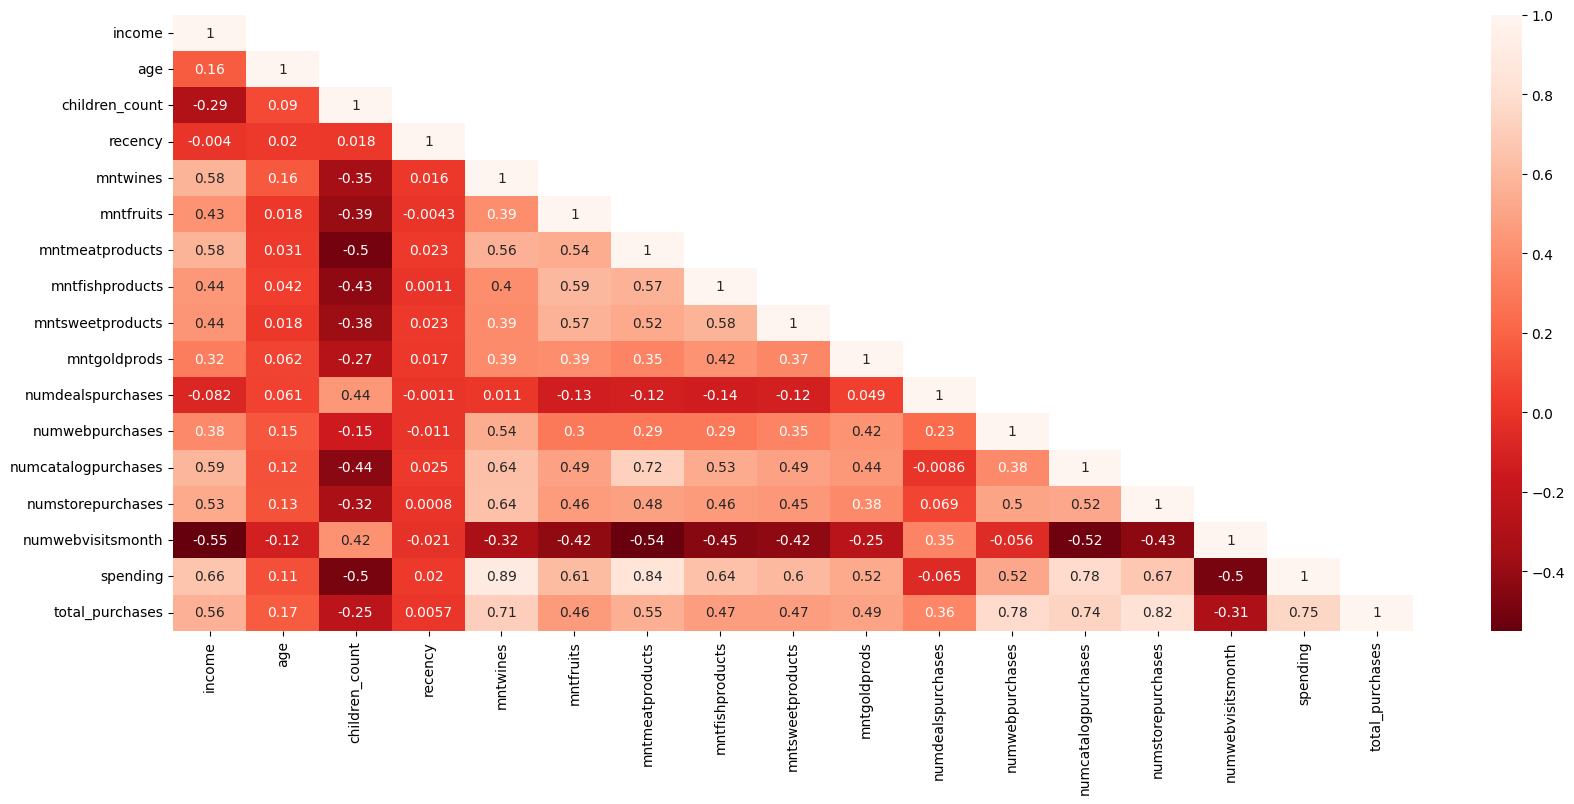

In [22]:
var_cor = ['income', 'age', 'children_count', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth','spending', 'total_purchases'
       ]

cor_data = new_data[var_cor].corr()

plt.figure(figsize = (20,8))
m = np.ones_like(cor_data)
m[np.tril_indices_from(m)]= 0
sns.heatmap(cor_data, mask = m, annot = True, cmap = 'Reds_r')
plt.show()

### 7.	Test the following hypotheses:
a.	Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.


In [23]:
store = new_data.loc[new_data.age >= 60, 'numstorepurchases']
web = new_data.loc[new_data.age >= 60, 'numwebpurchases']
t_score, p_val  = stats.ttest_ind(store,web )

p_val

np.float64(3.2717649057254646e-36)

In [24]:
#Since p value is much less than alpha of 5% we shall reject the null hypothesis and conclude that older customers prefer store purchases

b.	Customers with children likely experience time constraints, making online shopping a more convenient option.

In [25]:
online = new_data.loc[new_data.has_children == 1,'numwebpurchases']
store_p = new_data.loc[new_data.has_children == 1,'numstorepurchases']
t_score, p_val  = stats.ttest_ind(online, store_p)

p_val

np.float64(9.231326489220785e-32)

In [26]:
#Since p value is much less than alpha of 5% we shall reject the null hypothesis and conclude that customers with children prefer online shopping.

c.	Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

In [27]:
other = new_data.loc[:,['numwebpurchases', 'numcatalogpurchases']].sum(axis = 1)
store = new_data.loc[:, 'numstorepurchases']
t_score, p_val  = stats.ttest_ind(other, store)

p_val

np.float64(3.942648895317914e-15)

In [28]:
#Since p value is much less than alpha of 5% we shall reject the null hypothesis and conclude that Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

d.	Does the United States significantly outperform the rest of the world in total purchase volumes?

In [29]:
total_purchases_us = new_data.loc[new_data.country == "US",'total_purchases']
total_purchases_row = new_data.loc[new_data.country != "US",'total_purchases']
t_score, p_val  = stats.ttest_ind(total_purchases_us ,total_purchases_row)

p_val

np.float64(0.07121562869350609)

In [30]:
#Since p value is 0.07 is highwe than 0.05 or alpha of 5% we shall accept the null hypothesis and conclude that while the US might have slightly higher purchase volumes on average, your dataset does not provide strong enough mathematical proof to back up that claim firmly.

### 8.	Use appropriate visualization to help analyze the following:

a.	Identify the top-performing products and those with the lowest revenue.

/tmp/ipykernel_1418/3448348668.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(prod_data[i], xy = (i-0.15, prod_data[i]+2), size =15 , weight = 'heavy')


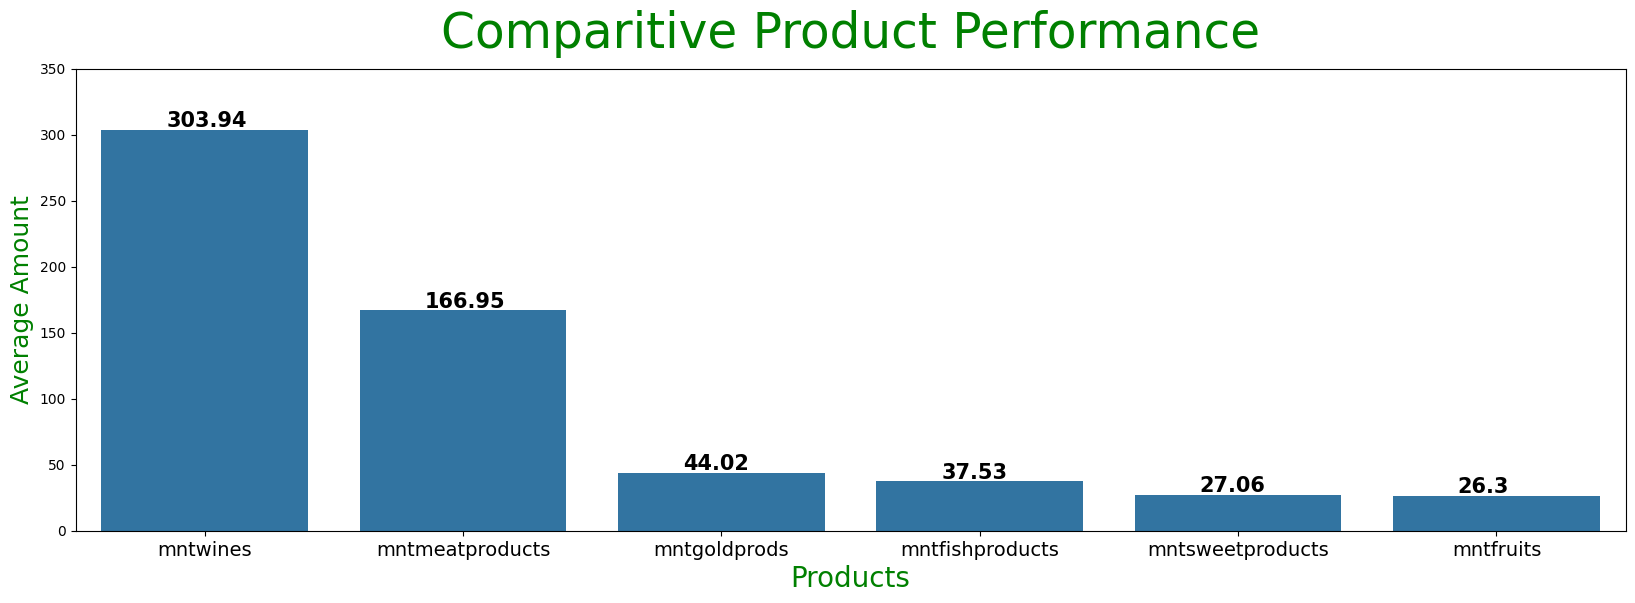

In [31]:
prod_data = new_data.loc[:,new_data.columns.str.startswith('mnt')].mean().round(2).sort_values(ascending = False)
plt.figure(figsize = (20,6))
sns.barplot(x = prod_data.index, y = prod_data.values, order=prod_data.index)
for i in range(prod_data.size):
  plt.annotate(prod_data[i], xy = (i-0.15, prod_data[i]+2), size =15 , weight = 'heavy')
plt.ylim(0, 350)
plt.xlabel( 'Products', size = 20, color = 'green')
plt.ylabel( 'Average Amount', size = 18, color = 'green')
plt.title('Comparitive Product Performance', size = 35, pad = 15, color = 'green')
plt.xticks(size = 14)
plt.show()

In [ ]:
#From the above Products v/s Average Amount bar diagram, we can say that wines are the best performing product and fruits have the lowest revenue generated.

b.	Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.

/tmp/ipykernel_1418/3277371680.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grpd_age = data.groupby('age_grp')['age'].agg(['min','max'])
/tmp/ipykernel_1418/3277371680.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data.age_grp = data.age_grp.replace([1,2,3,4,5], grpd_age.group)


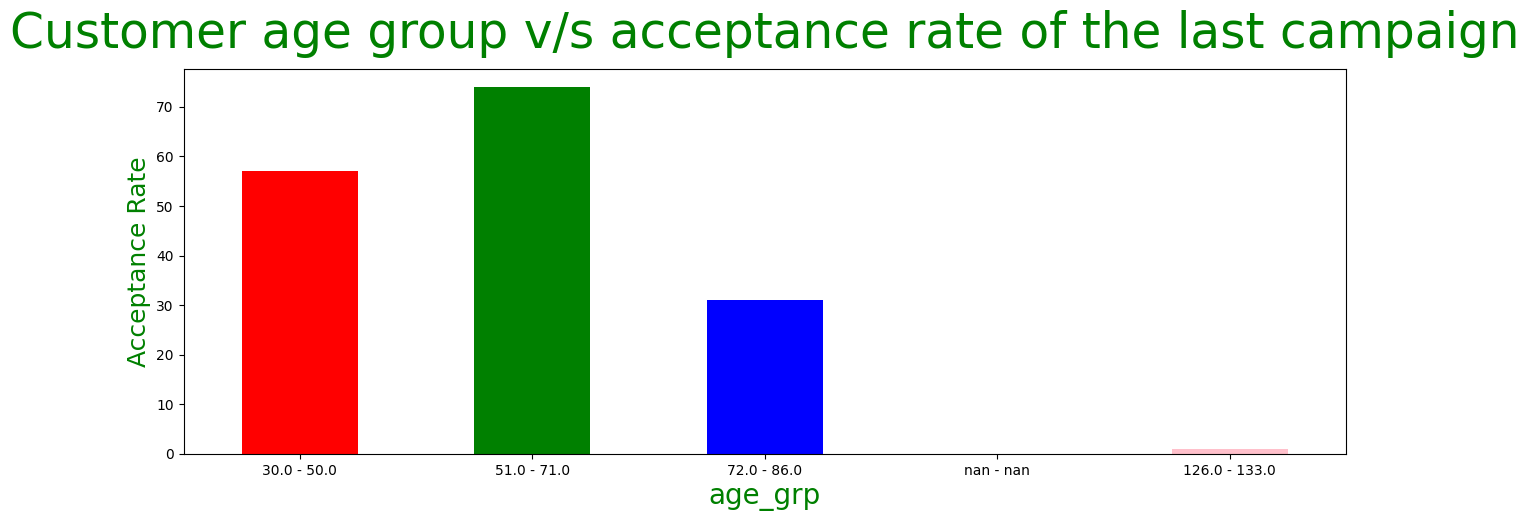

In [38]:
data['age_grp'] = pd.cut(data.age, bins = 5, labels = [1,2,3,4,5])
grpd_age = data.groupby('age_grp')['age'].agg(['min','max'])
grpd_age['group'] = grpd_age['min'].astype(str) + ' - ' +grpd_age['max'].astype(str)
data.age_grp = data.age_grp.replace([1,2,3,4,5], grpd_age.group)
vc = data[data.acceptedcmp5 == 1].age_grp.value_counts().sort_index()
plt.figure(figsize = (15,5))
plt.xlabel( 'Age Groups', size = 20, color = 'green')
plt.ylabel( 'Acceptance Rate', size = 18, color = 'green')
plt.title('Customer age group v/s acceptance rate of the last campaign', size = 35, pad = 15, color = 'green')
vc.plot.bar(color = ['red', 'green', 'blue', 'brown', 'pink'])
plt.xticks(rotation = 0)
plt.show()

In [ ]:
#The bar plot above shows that the age group pf 51 to 71 has accepted the last campaign the most.

c.	Determine the country with the highest number of customers who accepted the last campaign.

/tmp/ipykernel_1418/2207211458.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(accptd_data[i], xy = (i-0.05, accptd_data[i]+2), size =15 , weight = 'heavy')


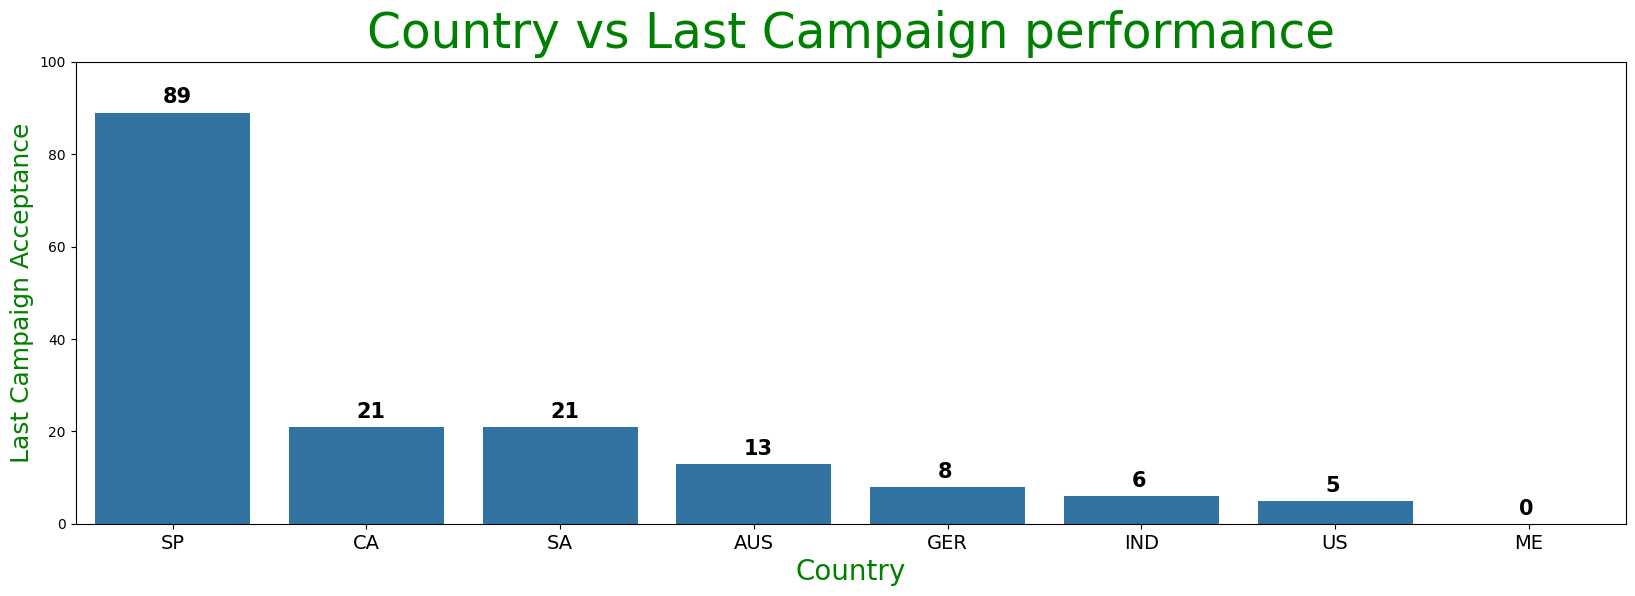

In [36]:
accptd_data = new_data.groupby('country')[['acceptedcmp5']].agg('sum').squeeze().sort_values(ascending = False)
plt.figure(figsize = (20,6))
sns.barplot(x = accptd_data.index, y = accptd_data.values, order=accptd_data.index)
for i in range(accptd_data.size):
  plt.annotate(accptd_data[i], xy = (i-0.05, accptd_data[i]+2), size =15 , weight = 'heavy')
plt.ylim(0,100)
plt.xlabel( 'Country', size = 20, color = 'green')
plt.ylabel( 'Last Campaign Acceptance', size = 18, color = 'green')
plt.title('Country vs Last Campaign performance', size = 35, pad = 10, color = 'green')
plt.xticks(size = 14)
plt.show()

d.	Investigate if there is a discernible pattern in the number of children at home and the total expenditure.

children_count
0    1106.029781
1     472.733156
2     245.947743
3     274.603774
Name: spending, dtype: float64


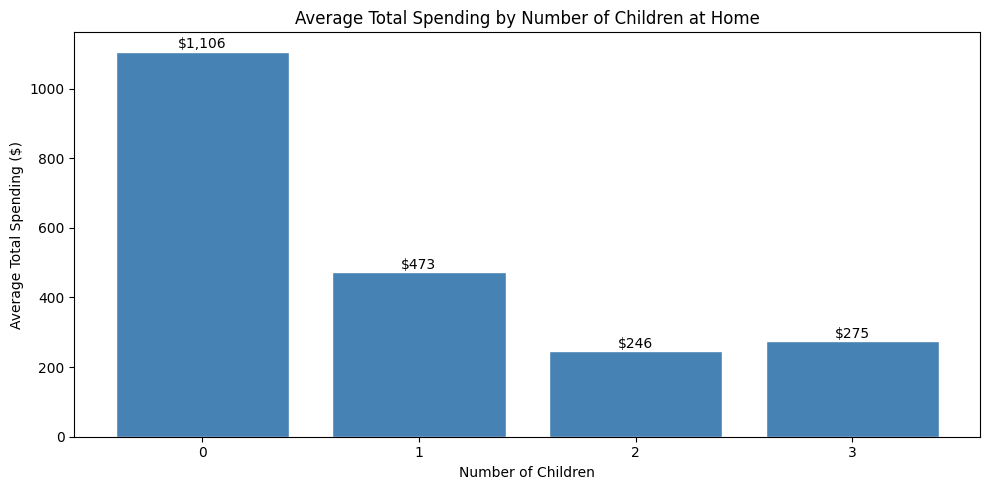

In [42]:
## ── Step 1: Calculate mean spending per number of children ─
children_spending = new_data.groupby('children_count')['spending'].mean()

print(children_spending)

# ── Step 2: Plot ───────────────────────────────────────────
plt.figure(figsize=(10, 5))

plt.bar(children_spending.index.astype(str),
        children_spending.values,
        color='steelblue',
        edgecolor='white')

plt.title('Average Total Spending by Number of Children at Home')
plt.xlabel('Number of Children')
plt.ylabel('Average Total Spending ($)')

# Add value labels on top
for i, val in enumerate(children_spending.values):
    plt.text(i, val + 10, f'${val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [43]:
#From the above bar plot, we can say that the spendings are singnificatly more when there is no children at home.

e.	Analyze the educational background of customers who lodged complaints in the last two years.

Total complainers: 21
education
Graduation    14
2n Cycle       4
Master         2
PhD            1
Name: count, dtype: int64


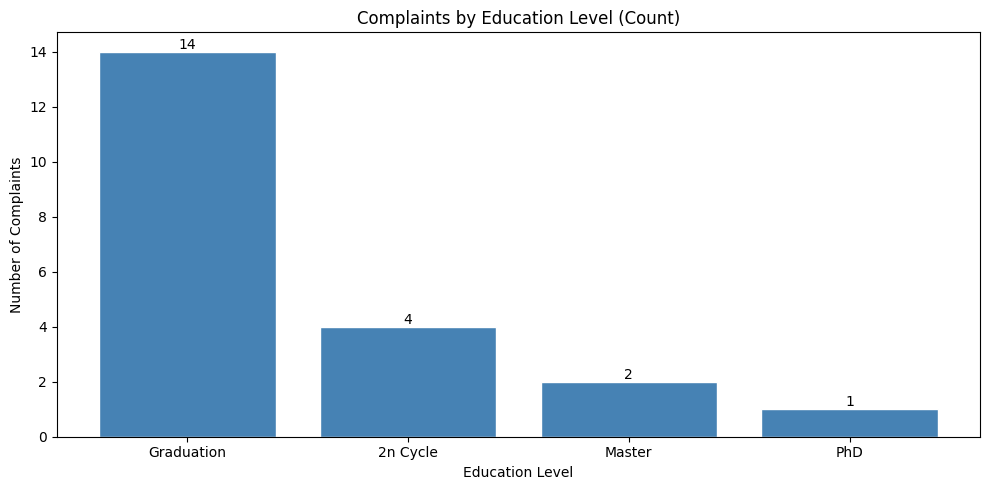


Complaint Rate per Education:
education
2n Cycle      1.970443
Graduation    1.242236
Master        0.540541
PhD           0.205761
Basic         0.000000
Name: count, dtype: float64


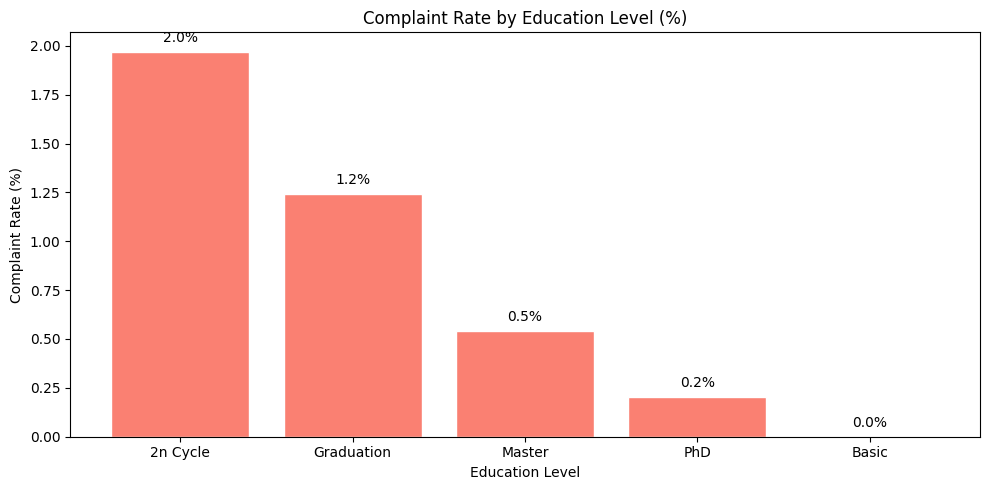

In [54]:
# ── Step 1: Filter only customers who complained ───────────
complaints = complaints = data[data['complain'] == 1]

print("Total complainers:", len(complaints))
print(complaints['education'].value_counts())

# ── Step 2: Count complaints per education level ───────────
education_count = complaints['education'].value_counts()

# ── Step 3: Plot count ─────────────────────────────────────
plt.figure(figsize=(10, 5))

plt.bar(education_count.index,
        education_count.values,
        color='steelblue',
        edgecolor='white')

plt.title('Complaints by Education Level (Count)')
plt.xlabel('Education Level')
plt.ylabel('Number of Complaints')

for i, val in enumerate(education_count.values):
    plt.text(i, val + 0.1, str(int(val)), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# ── Step 4: Complaint rate per education ───────────────────
# Count is misleading — Graduation has most customers overall
# Rate gives fair comparison
total_per_education   = data['education'].value_counts()
complaint_rate        = (education_count / total_per_education * 100).fillna(0)
complaint_rate        = complaint_rate.sort_values(ascending=False)

print("\nComplaint Rate per Education:")
print(complaint_rate)

# ── Step 5: Plot rate ──────────────────────────────────────
plt.figure(figsize=(10, 5))

plt.bar(complaint_rate.index,
        complaint_rate.values,
        color='salmon',
        edgecolor='white')

plt.title('Complaint Rate by Education Level (%)')
plt.xlabel('Education Level')
plt.ylabel('Complaint Rate (%)')

for i, val in enumerate(complaint_rate.values):
    plt.text(i, val + 0.05, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()